In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [9]:
df = pd.read_csv('workout_data.csv')

df['start_time'] = pd.to_datetime(df['start_time'], format='%d %b %Y, %H:%M')
df['end_time'] = pd.to_datetime(df['end_time'], format='%d %b %Y, %H:%M')
df['duration_mins'] = (df['end_time'] - df['start_time']).dt.total_seconds() / 60
df['weight_kg'] = df['weight_kg'].fillna(81) # I am 81kg, this is to fill in the empty weight values (pull-ups, dips) with my weight
df['volume'] = df['reps'] * df['weight_kg']

In [ ]:
workouts = df.groupby('start_time').agg(duration_mins=('duration_mins', 'first'), volume=('volume', 'sum')).reset_index()
workouts['volume_per_min'] = workouts['volume'] / workouts['duration_mins']

workouts = workouts.sort_values('start_time')
workouts['Hours_Since_Last_Workout'] = workouts['start_time'].diff().dt.total_seconds() / 3600
workouts['Hours_Since_Last_Workout'] = workouts['Hours_Since_Last_Workout'].fillna(0) # First workout has no previous workout, so we set it to 0

,start_time,duration_mins,volume,volume_per_min,Hours_Since_Last_Workout
0,2025-05-10 14:40:00,63.0,5349.00,84.904762,48.000000
1,2025-05-11 14:53:00,124.0,4411.47,35.576371,24.216667
2,2025-05-12 14:24:00,148.0,6483.83,43.809662,23.516667
3,2025-05-13 14:54:00,100.0,5501.50,55.015000,24.500000
4,2025-05-14 12:24:00,120.0,3915.15,32.626250,21.500000
...,...,...,...,...,...
91,2026-04-02 09:58:00,71.0,5155.00,72.605634,47.233333
92,2026-04-04 16:24:00,85.0,8446.62,99.372000,54.433333
93,2026-04-07 09:23:00,76.0,3751.00,49.355263,64.983333
94,2026-04-09 09:46:00,72.0,4445.00,61.736111,48.383333


In [37]:
fall_semester = (workouts['start_time'] > '2025-09-15') & (workouts['start_time'] < '2026-01-14')
spring_semester = (workouts['start_time'] >= '2026-02-16')

fall_workouts = workouts[fall_semester].copy()
spring_workouts = workouts[spring_semester].copy()

fall_workouts['Days_Since_Start'] = (fall_workouts['start_time'] - fall_workouts['start_time'].min()).dt.days
spring_workouts['Days_Since_Start'] = (spring_workouts['start_time'] - spring_workouts['start_time'].min()).dt.days

fall_workouts['Phase'] = 'Fall (Random)'
spring_workouts['Phase'] = 'Spring (Morning)'

clean_data = pd.concat([fall_workouts, spring_workouts])

<Figure size 1200x600 with 0 Axes>

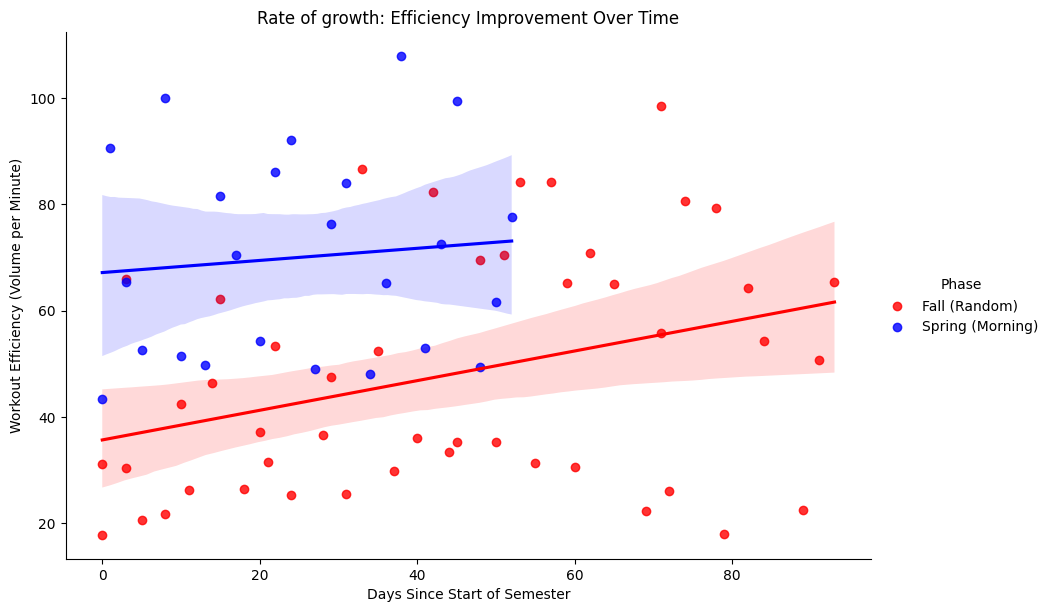

In [38]:
plt.figure(figsize=(12, 6))
sns.lmplot(
    data=clean_data,
    x='Days_Since_Start',
    y='volume_per_min',
    hue='Phase',
    palette=['red', 'blue'],
    height=6,
    aspect=1.5
)
plt.title('Rate of growth: Efficiency Improvement Over Time')
plt.xlabel('Days Since Start of Semester')
plt.ylabel('Workout Efficiency (Volume per Minute)')
plt.show()

In [26]:
print("\n--- Rate of Growth Analysis ---")
fall_slope, _, _, _, _ = stats.linregress(fall_workouts['Days_Since_Start'], fall_workouts['volume_per_min'])

spring_slope, _, _, _, _ = stats.linregress(spring_workouts['Days_Since_Start'], spring_workouts['volume_per_min'])

print(f"Fall Semester Growth Rate: +{fall_slope:.2f} kg/minute per day")
print(f"Spring Semester Growth Rate: +{spring_slope:.2f} kg/minute per day")

if spring_slope > fall_slope:
    print("\nThe morning workout phase (Spring) shows a faster progression than the random workout phase (Fall).")
    print("This proves that the morning workout phase is more effective for improving workout efficiency.")
else:
    print("\nThe random workout phase (Fall) shows a faster rate of growth than the morning workout phase (Spring).")


--- Rate of Growth Analysis ---
Fall Semester Growth Rate: +0.28 kg/minute per day
Spring Semester Growth Rate: +0.11 kg/minute per day

The random workout phase (Fall) shows a faster rate of growth than the morning workout phase (Spring).


Although the initial hypothesis was that the Spring Morning routine would yield a faster rate of progression than the random Fall routine, the linear regression proves the Fall semester had a steeper growth slope. However, I must acknowledge 2 confounding variables that inflated the Fall growth rate:
1. The Fall semester was followed by a 4 months pause in training. In sports science, coming back to training and regaining the lost muscle causes an aggressive non-linear spike due to Muscle Memory.
2. During the entire Fall semester, I supplemented with Creatine which I stopped prior to the beginning of Spring semester. Because this omitted variable perfectly correlates with the Fall semester, the model cannot isolate whether the faster rate of progression was caused by the random times, or the additional supplements.

Therefore, while the Fall semester had a faster rate of progression, it cannot be definitvely attributed to the random times of day. 